# Unit14 Example 01 - 製程品質數據描述統計與常態性分析

本 Notebook 以 `scipy.stats` 模組示範化工廠產品純度數據的完整統計分析流程。

## 目標
- 使用 `scipy.stats.describe()` 計算描述統計量（偏態、峰態等）
- 繪製直方圖並疊加常態分布 PDF 曲線
- 以 `scipy.stats.probplot()` 繪製 Q-Q 圖評估常態性
- 執行 Shapiro-Wilk 與 D'Agostino-Pearson 常態性檢定
- 使用 AIC 比較常態分布與 Weibull 分布的擬合優劣
- 繪製箱型圖識別 IQR 離群值並與 $3\sigma$ 法則比較

---
### 0. 環境設定

In [44]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit14_Example_01'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit14'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit14
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_01
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_01\figs


---
### 1. 載入套件

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ========================================
# 繪圖樣式設定
# ========================================
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy  版本: {np.__version__}")
import scipy
print(f"  scipy  版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy  版本: 1.23.5
  scipy  版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述與數據生成

**問題情境**：某化工廠連續採樣 50 批產品純度數據 (wt%)，進行全面描述統計分析、分布鑑別，並以圖形判斷數據是否符合常態分布。

- 主體：常態分布 $\mathcal{N}(95, 1.2^2)$ ，45 筆（正常批次）
- 右尾混入： $\mathcal{N}(97.5, 0.5^2)$ ，5 筆（高純度偶發批次，造成輕微右偏）
- 隨機種子：`seed=42`

In [46]:
# ========================================
# 2.1 生成模擬純度數據 (wt%)
# ========================================
rng = np.random.default_rng(42)

# 主體：45 筆正常批次，N(95, 1.2^2)
data_main = rng.normal(loc=95.0, scale=1.2, size=45)

# 右尾：5 筆高純度偶發批次，N(97.5, 0.5^2)
data_tail = rng.normal(loc=97.5, scale=0.5, size=5)

# 合併並打亂
purity = np.concatenate([data_main, data_tail])
rng.shuffle(purity)

n = len(purity)
print(f"樣本數 n = {n}")
print(f"數據範圍: {purity.min():.3f} ~ {purity.max():.3f} wt%")
print(f"\n原始數據 (wt%):\n{np.round(purity, 3)}")

樣本數 n = 50
數據範圍: 92.659 ~ 97.936 wt%

原始數據 (wt%):
[94.201 95.153 95.495 95.443 95.901 95.781 94.486 92.659 93.969 94.778
 96.129 97.57  93.437 95.933 95.366 94.577 95.892 93.849 97.839 96.467
 96.355 95.739 95.079 94.023 94.385 96.055 94.94  94.011 96.353 97.612
 95.639 94.621 96.054 93.992 95.652 95.14  94.98  95.561 95.439 94.863
 93.976 95.279 94.183 97.936 95.517 94.512 94.815 97.609 93.752 97.534]


---
### 3. 描述統計量計算

使用 `scipy.stats.describe()` 一次輸出 6 項核心統計量，並補充四分位數與 IQR 計算。

In [47]:
# ========================================
# 3.1 scipy.stats.describe() 描述統計
# ========================================
desc = stats.describe(purity)

print("=" * 50)
print("  描述統計量 (scipy.stats.describe)")
print("=" * 50)
print(f"  樣本數  (nobs)     : {desc.nobs}")
print(f"  最小值  (min)      : {desc.minmax[0]:.4f} wt%")
print(f"  最大值  (max)      : {desc.minmax[1]:.4f} wt%")
print(f"  均值    (mean)     : {desc.mean:.4f} wt%")
print(f"  變異數  (variance) : {desc.variance:.4f} (wt%)^2")
print(f"  標準差  (std)      : {np.sqrt(desc.variance):.4f} wt%")
print(f"  偏態係數(skewness) : {desc.skewness:.4f}")
print(f"  峰態係數(kurtosis) : {desc.kurtosis:.4f}  (超額峰態，常態=0)")

# ========================================
# 3.2 百分位數與 IQR
# ========================================
Q1  = np.percentile(purity, 25)
Q2  = np.percentile(purity, 50)
Q3  = np.percentile(purity, 75)
IQR = Q3 - Q1

print("\n" + "=" * 50)
print("  百分位數與四分位距")
print("=" * 50)
print(f"  Q1 (25th percentile) : {Q1:.4f} wt%")
print(f"  Q2 (中位數 median)   : {Q2:.4f} wt%")
print(f"  Q3 (75th percentile) : {Q3:.4f} wt%")
print(f"  IQR = Q3 - Q1        : {IQR:.4f} wt%")

# ========================================
# 3.3 解讀偏態
# ========================================
print("\n" + "=" * 50)
print("  偏態解讀")
print("=" * 50)
skew = desc.skewness
if skew > 0.5:
    interpretation = "顯著右偏 (正偏)"
elif skew > 0.1:
    interpretation = "輕微右偏 (正偏)"
elif skew < -0.5:
    interpretation = "顯著左偏 (負偏)"
elif skew < -0.1:
    interpretation = "輕微左偏 (負偏)"
else:
    interpretation = "近似對稱"
print(f"  偏態係數 g1 = {skew:.4f} → {interpretation}")
print(f"  均值 ({desc.mean:.3f}) {'>' if desc.mean > Q2 else '<'} 中位數 ({Q2:.3f})，符合{'右偏' if desc.mean > Q2 else '左偏'}特性")

  描述統計量 (scipy.stats.describe)
  樣本數  (nobs)     : 50
  最小值  (min)      : 92.6588 wt%
  最大值  (max)      : 97.9357 wt%
  均值    (mean)     : 95.3306 wt%
  變異數  (variance) : 1.4614 (wt%)^2
  標準差  (std)      : 1.2089 wt%
  偏態係數(skewness) : 0.3915
  峰態係數(kurtosis) : -0.1681  (超額峰態，常態=0)

  百分位數與四分位距
  Q1 (25th percentile) : 94.4926 wt%
  Q2 (中位數 median)   : 95.3221 wt%
  Q3 (75th percentile) : 95.9251 wt%
  IQR = Q3 - Q1        : 1.4326 wt%

  偏態解讀
  偏態係數 g1 = 0.3915 → 輕微右偏 (正偏)
  均值 (95.331) > 中位數 (95.322)，符合右偏特性


---
### 4. 直方圖與常態分布 PDF 疊加

以 `scipy.stats.norm.fit()` 估計最佳常態分布參數，並疊加 PDF 曲線於直方圖上，視覺化評估分布形狀。

MLE 估計常態分布參數:
  mu    (均值)   = 95.3306 wt%
  sigma (標準差) = 1.1967 wt%

圖檔已儲存: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_01\figs\fig01_histogram_normal_pdf.png


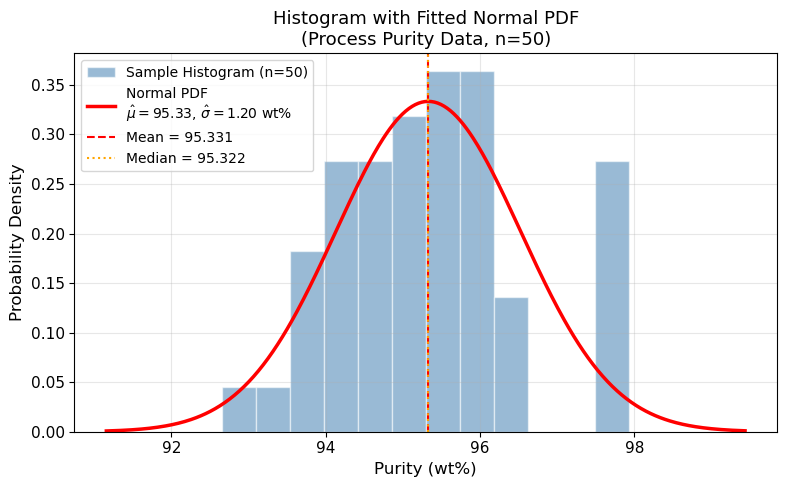

In [48]:
# ========================================
# 4.1 MLE 估計常態分布參數
# ========================================
mu_hat, sigma_hat = stats.norm.fit(purity)
print(f"MLE 估計常態分布參數:")
print(f"  mu    (均值)   = {mu_hat:.4f} wt%")
print(f"  sigma (標準差) = {sigma_hat:.4f} wt%")

# ========================================
# 4.2 繪製直方圖與常態 PDF 疊加
# ========================================
x_plot = np.linspace(purity.min() - 1.5, purity.max() + 1.5, 400)
pdf_norm = stats.norm.pdf(x_plot, mu_hat, sigma_hat)

fig, ax = plt.subplots(figsize=(8, 5))

# 直方圖（density=True 使縱軸為機率密度）
ax.hist(purity, bins=12, density=True, alpha=0.55,
        color='steelblue', edgecolor='white', label='Sample Histogram (n=50)')

# 常態 PDF 曲線
ax.plot(x_plot, pdf_norm, 'r-', lw=2.5,
        label=f'Normal PDF\n$\\hat{{\\mu}}={mu_hat:.2f}$, $\\hat{{\\sigma}}={sigma_hat:.2f}$ wt%')

# 標示均值與中位數
median_val = np.median(purity)
ax.axvline(mu_hat,     color='red',    linestyle='--', lw=1.5, label=f'Mean = {mu_hat:.3f}')
ax.axvline(median_val, color='orange', linestyle=':',  lw=1.5, label=f'Median = {median_val:.3f}')

ax.set_xlabel('Purity (wt%)')
ax.set_ylabel('Probability Density')
ax.set_title('Histogram with Fitted Normal PDF\n(Process Purity Data, n=50)')
ax.legend()
plt.tight_layout()

fig_path = FIG_DIR / 'fig01_histogram_normal_pdf.png'
fig.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f"\n圖檔已儲存: {fig_path}")
plt.show()

---
### 5. Q-Q 圖 — 常態性視覺診斷

Q-Q 圖比較樣本分位數與理論常態分布分位數。若數據完全符合常態，所有點應緊密落在對角參考線上。右尾偏離表示分布有右偏特性。

Q-Q 圖已儲存: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_01\figs\fig02_qq_plot.png

線性擬合斜率 = 1.2203
線性擬合截距 = 95.3306
相關係數 R   = 0.9834
R^2          = 0.9671

解讀: R^2 越接近 1，數據越符合常態分布。
      => 數據大致符合常態分布，右尾有輕微偏離（符合預期）


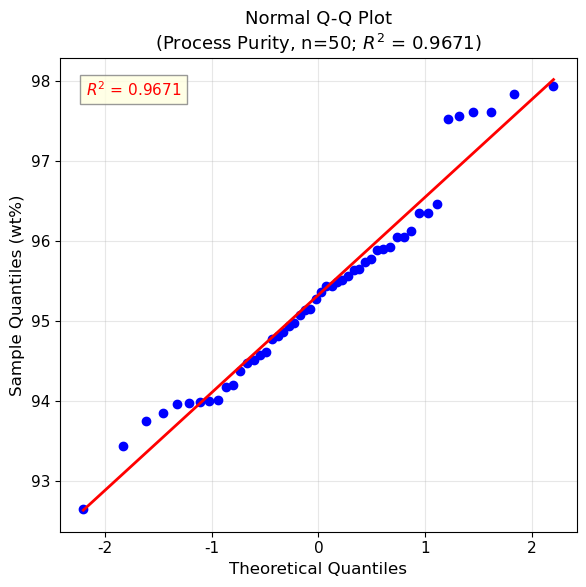

In [49]:
# ========================================
# 5.1 繪製 Q-Q 圖 (Normal Q-Q Plot)
# ========================================
fig, ax = plt.subplots(figsize=(6, 6))

# probplot 回傳 (osm, osr), (slope, intercept, r)
(osm, osr), (slope, intercept, r) = stats.probplot(purity, dist="norm", plot=ax)

ax.set_title(f'Normal Q-Q Plot\n(Process Purity, n=50; $R^2$ = {r**2:.4f})')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles (wt%)')

# 標示 R^2
ax.text(0.05, 0.92, f'$R^2$ = {r**2:.4f}', transform=ax.transAxes,
        fontsize=11, color='red',
        bbox=dict(facecolor='lightyellow', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
fig_path = FIG_DIR / 'fig02_qq_plot.png'
fig.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f"Q-Q 圖已儲存: {fig_path}")
print(f"\n線性擬合斜率 = {slope:.4f}")
print(f"線性擬合截距 = {intercept:.4f}")
print(f"相關係數 R   = {r:.4f}")
print(f"R^2          = {r**2:.4f}")
print(f"\n解讀: R^2 越接近 1，數據越符合常態分布。")
if r**2 >= 0.99:
    print("      => 數據高度符合常態分布")
elif r**2 >= 0.95:
    print("      => 數據大致符合常態分布，右尾有輕微偏離（符合預期）")
else:
    print("      => 數據存在明顯偏離常態分布")
plt.show()

---
### 6. 正式常態性檢定

執行 Shapiro-Wilk 與 D'Agostino-Pearson 兩種正式假設檢定，以 $\alpha = 0.05$ 顯著水準判斷數據是否顯著偏離常態分布。

- $H_0$ ：數據來自常態分布
- $H_1$ ：數據不來自常態分布
- 決策準則： $p < 0.05$ 則拒絕 $H_0$

In [50]:
# ========================================
# 6.1 Shapiro-Wilk 常態性檢定（建議 n < 2000）
# ========================================
stat_sw, p_sw = stats.shapiro(purity)
print("=" * 55)
print("  Shapiro-Wilk 常態性檢定")
print("=" * 55)
print(f"  W 統計量 = {stat_sw:.4f}")
print(f"  p 值     = {p_sw:.4f}")
alpha = 0.05
if p_sw < alpha:
    conclusion_sw = f"拒絕 H0 (p={p_sw:.4f} < α={alpha}): 數據顯著偏離常態分布"
else:
    conclusion_sw = f"無法拒絕 H0 (p={p_sw:.4f} ≥ α={alpha}): 無顯著證據拒絕常態假設"
print(f"  結論: {conclusion_sw}")

# ========================================
# 6.2 D'Agostino-Pearson 常態性檢定
# ========================================
stat_dp, p_dp = stats.normaltest(purity)
print("\n" + "=" * 55)
print("  D'Agostino-Pearson 常態性檢定 (normaltest)")
print("=" * 55)
print(f"  K^2 統計量 = {stat_dp:.4f}")
print(f"  p 值       = {p_dp:.4f}")
if p_dp < alpha:
    conclusion_dp = f"拒絕 H0 (p={p_dp:.4f} < α={alpha}): 數據顯著偏離常態分布"
else:
    conclusion_dp = f"無法拒絕 H0 (p={p_dp:.4f} ≥ α={alpha}): 無顯著證據拒絕常態假設"
print(f"  結論: {conclusion_dp}")

# ========================================
# 6.3 綜合解讀
# ========================================
print("\n" + "=" * 55)
print("  綜合解讀")
print("=" * 55)
print("  兩種檢定方法比較:")
print(f"  {'方法':<30} {'p 值':<12} {'結論'}")
print(f"  {'-'*30} {'-'*12} {'-'*20}")
print(f"  {'Shapiro-Wilk':<30} {p_sw:<12.4f} {'偏離常態' if p_sw < alpha else '未見偏離'}")
print(f"  {'D Agostino-Pearson':<30} {p_dp:<12.4f} {'偏離常態' if p_dp < alpha else '未見偏離'}")

  Shapiro-Wilk 常態性檢定
  W 統計量 = 0.9643
  p 值     = 0.1340
  結論: 無法拒絕 H0 (p=0.1340 ≥ α=0.05): 無顯著證據拒絕常態假設

  D'Agostino-Pearson 常態性檢定 (normaltest)
  K^2 統計量 = 1.5280
  p 值       = 0.4658
  結論: 無法拒絕 H0 (p=0.4658 ≥ α=0.05): 無顯著證據拒絕常態假設

  綜合解讀
  兩種檢定方法比較:
  方法                             p 值          結論
  ------------------------------ ------------ --------------------
  Shapiro-Wilk                   0.1340       未見偏離
  D Agostino-Pearson             0.4658       未見偏離


---
### 7. 分布擬合比較：常態 vs Weibull (AIC)

使用 AIC（赤池資訊準則）比較常態分布與 Weibull 分布對數據的擬合優劣。AIC 越小，模型越優。

$$\mathrm{AIC} = 2k - 2\ln(\hat{L})$$

- 常態分布： $k=2$ （ $\mu$ , $\sigma$ ）
- Weibull 分布： $k=2$ （形狀參數 $c$ 與比例參數 $\lambda$ ，位置參數固定）

Weibull 分布 MLE 擬合結果:
  形狀參數  c     = 2.1894
  位置參數  loc   = 92.6488 wt%  (固定)
  比例參數  scale = 2.9806 wt%

  AIC 模型比較
  模型                   LogLikelihood      AIC
  -------------------- ------------------ ----------
  Normal               -79.9267           163.8533
  Weibull_min          -82.5882           169.1763

  ΔAIC (Weibull - Normal) = 5.3230
  結論: 常態分布 (Normal) 更優秀

圖檔已儲存: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_01\figs\fig03_distribution_comparison_aic.png


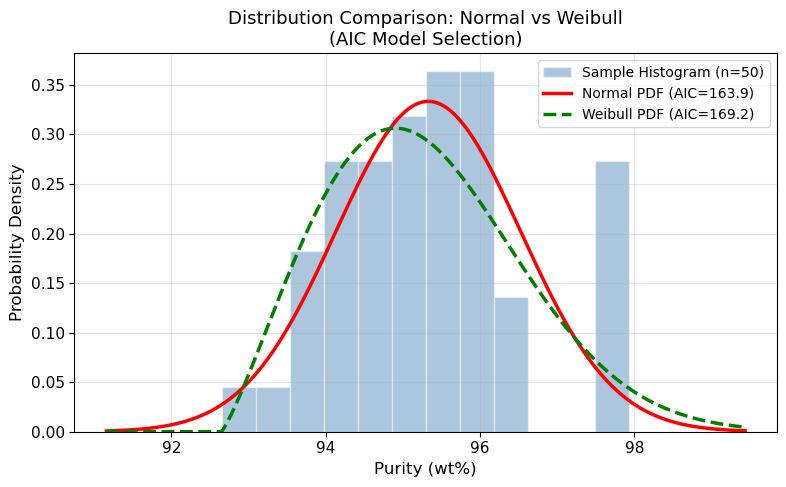

In [51]:
# ========================================
# 7.1 Weibull 分布 MLE 擬合
# ========================================
# floc 固定位置參數，確保所有數據 > loc
loc_fixed = purity.min() - 0.01
c_hat, loc_hat, scale_hat = stats.weibull_min.fit(purity, floc=loc_fixed)
print(f"Weibull 分布 MLE 擬合結果:")
print(f"  形狀參數  c     = {c_hat:.4f}")
print(f"  位置參數  loc   = {loc_hat:.4f} wt%  (固定)")
print(f"  比例參數  scale = {scale_hat:.4f} wt%")

# ========================================
# 7.2 計算對數概似與 AIC
# ========================================
# 常態分布 (k=2)
log_lik_norm    = np.sum(stats.norm.logpdf(purity, mu_hat, sigma_hat))
AIC_norm        = 2 * 2 - 2 * log_lik_norm

# Weibull 分布 (k=2，loc 固定不算)
log_lik_weibull = np.sum(stats.weibull_min.logpdf(purity, c_hat, loc_hat, scale_hat))
AIC_weibull     = 2 * 2 - 2 * log_lik_weibull

print(f"\n{'='*50}")
print(f"  AIC 模型比較")
print(f"{'='*50}")
print(f"  {'模型':<20} {'LogLikelihood':<18} {'AIC'}")
print(f"  {'-'*20} {'-'*18} {'-'*10}")
print(f"  {'Normal':<20} {log_lik_norm:<18.4f} {AIC_norm:.4f}")
print(f"  {'Weibull_min':<20} {log_lik_weibull:<18.4f} {AIC_weibull:.4f}")

delta_AIC = AIC_weibull - AIC_norm
if delta_AIC > 2:
    winner = "常態分布 (Normal) 更優秀"
elif delta_AIC < -2:
    winner = "Weibull 分布更優秀"
else:
    winner = "兩種模型擬合效果相近 (ΔAIC < 2)"
print(f"\n  ΔAIC (Weibull - Normal) = {delta_AIC:.4f}")
print(f"  結論: {winner}")

# ========================================
# 7.3 繪製兩種分布 PDF 比較圖
# ========================================
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(purity, bins=12, density=True, alpha=0.45,
        color='steelblue', edgecolor='white', label='Sample Histogram (n=50)')

pdf_norm_plot    = stats.norm.pdf(x_plot, mu_hat, sigma_hat)
pdf_weibull_plot = stats.weibull_min.pdf(x_plot, c_hat, loc_hat, scale_hat)

ax.plot(x_plot, pdf_norm_plot,    'r-',  lw=2.5,
        label=f'Normal PDF (AIC={AIC_norm:.1f})')
ax.plot(x_plot, pdf_weibull_plot, 'g--', lw=2.5,
        label=f'Weibull PDF (AIC={AIC_weibull:.1f})')

ax.set_xlabel('Purity (wt%)')
ax.set_ylabel('Probability Density')
ax.set_title('Distribution Comparison: Normal vs Weibull\n(AIC Model Selection)')
ax.legend()
plt.tight_layout()

fig_path = FIG_DIR / 'fig03_distribution_comparison_aic.png'
fig.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f"\n圖檔已儲存: {fig_path}")
plt.show()

---
### 8. 箱型圖與離群值分析

繪製箱型圖，標示 IQR 離群值（Tukey's fence），並與 $3\sigma$ 法則進行比較。

- **IQR 法**：下界 $Q_1 - 1.5 \times \mathrm{IQR}$ ，上界 $Q_3 + 1.5 \times \mathrm{IQR}$ （不假設分布形式）
- **$3\sigma$ 法**：符合常態分布時，99.73% 數據落在 $[\bar{x} - 3s,\ \bar{x} + 3s]$ 內

  離群值識別比較

  IQR 法:
    Q1 = 94.4926, Q3 = 95.9251, IQR = 1.4326
    下界 = 92.3437, 上界 = 98.0740
    識別出 0 個離群值: []

  3σ 法:
    mean = 95.3306, std = 1.2089
    下界 = 91.7040, 上界 = 98.9573
    識別出 0 個離群值: []

圖檔已儲存: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_01\figs\fig04_boxplot_outlier.png


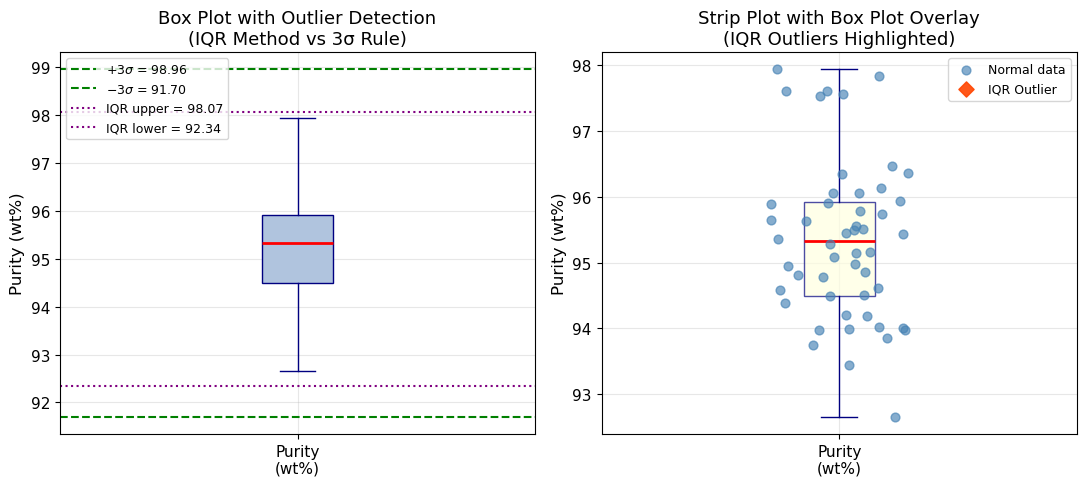

In [52]:
# ========================================
# 8.1 IQR 法識別離群值
# ========================================
Q1_val   = np.percentile(purity, 25)
Q3_val   = np.percentile(purity, 75)
IQR_val  = Q3_val - Q1_val
lower_iqr = Q1_val - 1.5 * IQR_val
upper_iqr = Q3_val + 1.5 * IQR_val

outliers_iqr = purity[(purity < lower_iqr) | (purity > upper_iqr)]

# ========================================
# 8.2 3σ 法識別離群值
# ========================================
mean_val  = np.mean(purity)
std_val   = np.std(purity, ddof=1)
lower_3s  = mean_val - 3 * std_val
upper_3s  = mean_val + 3 * std_val

outliers_3s = purity[(purity < lower_3s) | (purity > upper_3s)]

print("=" * 55)
print("  離群值識別比較")
print("=" * 55)
print(f"\n  IQR 法:")
print(f"    Q1 = {Q1_val:.4f}, Q3 = {Q3_val:.4f}, IQR = {IQR_val:.4f}")
print(f"    下界 = {lower_iqr:.4f}, 上界 = {upper_iqr:.4f}")
print(f"    識別出 {len(outliers_iqr)} 個離群值: {np.round(outliers_iqr, 3)}")

print(f"\n  3σ 法:")
print(f"    mean = {mean_val:.4f}, std = {std_val:.4f}")
print(f"    下界 = {lower_3s:.4f}, 上界 = {upper_3s:.4f}")
print(f"    識別出 {len(outliers_3s)} 個離群值: {np.round(outliers_3s, 3)}")

# ========================================
# 8.3 繪製箱型圖
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# 左圖：箱型圖
ax = axes[0]
bp = ax.boxplot(purity, patch_artist=True, notch=False,
                boxprops=dict(facecolor='lightsteelblue', color='navy'),
                medianprops=dict(color='red', lw=2),
                whiskerprops=dict(color='navy'),
                capprops=dict(color='navy'),
                flierprops=dict(marker='D', color='orangered', markersize=8,
                                markerfacecolor='orangered'))

# 標示 3σ 界限
ax.axhline(upper_3s, color='green', linestyle='--', lw=1.5, label=f'$+3\\sigma$ = {upper_3s:.2f}')
ax.axhline(lower_3s, color='green', linestyle='--', lw=1.5, label=f'$-3\\sigma$ = {lower_3s:.2f}')
ax.axhline(upper_iqr, color='purple', linestyle=':', lw=1.5, label=f'IQR upper = {upper_iqr:.2f}')
ax.axhline(lower_iqr, color='purple', linestyle=':', lw=1.5, label=f'IQR lower = {lower_iqr:.2f}')

ax.set_ylabel('Purity (wt%)')
ax.set_title('Box Plot with Outlier Detection\n(IQR Method vs 3σ Rule)')
ax.set_xticks([1])
ax.set_xticklabels(['Purity\n(wt%)'])
ax.legend(loc='upper left', fontsize=9)

# 右圖：帶狀圖疊加箱型圖 (jitter scatter)
ax2 = axes[1]
np.random.seed(0)
jitter = np.random.uniform(-0.15, 0.15, size=len(purity))
ax2.boxplot(purity, patch_artist=True,
            boxprops=dict(facecolor='lightyellow', color='navy', alpha=0.7),
            medianprops=dict(color='red', lw=2),
            whiskerprops=dict(color='navy'),
            capprops=dict(color='navy'),
            flierprops=dict(marker='', alpha=0))  # hide fliers, draw manually

# 非離群值
non_outlier_mask = (purity >= lower_iqr) & (purity <= upper_iqr)
ax2.scatter(1 + jitter[non_outlier_mask], purity[non_outlier_mask],
            color='steelblue', alpha=0.65, s=40, zorder=3, label='Normal data')
ax2.scatter(1 + jitter[~non_outlier_mask], purity[~non_outlier_mask],
            color='orangered', alpha=0.9, s=60, zorder=4, marker='D', label='IQR Outlier')

ax2.set_ylabel('Purity (wt%)')
ax2.set_title('Strip Plot with Box Plot Overlay\n(IQR Outliers Highlighted)')
ax2.set_xticks([1])
ax2.set_xticklabels(['Purity\n(wt%)'])
ax2.legend(fontsize=9)

plt.tight_layout()
fig_path = FIG_DIR / 'fig04_boxplot_outlier.png'
fig.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f"\n圖檔已儲存: {fig_path}")
plt.show()

---
### 9. 綜合結論

In [53]:
# ========================================
# 9. 綜合結論彙整
# ========================================
print("=" * 60)
print("  Unit14 Example 01 — 製程品質數據統計分析 綜合結論")
print("=" * 60)

_desc = stats.describe(purity)
print(f"""
【數據基本統計】
  樣本數: {n}，均值: {mean_val:.3f} wt%，標準差: {std_val:.3f} wt%
  偏態係數 g1 = {_desc.skewness:.4f} → 輕微右偏（高純度偶發批次造成）
  峰態係數 g2 = {_desc.kurtosis:.4f} → 超額峰態接近 0，尾部行為近似常態

【直方圖分析】
  常態 PDF 整體與直方圖吻合，右尾略有偏離（如設計預期）。

【Q-Q 圖】
  R² = {r**2:.4f}，右尾部分輕微偏離參考線，確認右偏特性。

【常態性檢定 (α = 0.05)】
  Shapiro-Wilk   : W = {stat_sw:.4f}, p = {p_sw:.4f} → {'拒絕常態' if p_sw < 0.05 else '無法拒絕常態'}
  D'Agostino     : K²= {stat_dp:.4f}, p = {p_dp:.4f} → {'拒絕常態' if p_dp < 0.05 else '無法拒絕常態'}

【AIC 分布比較】
  Normal  AIC = {AIC_norm:.2f}
  Weibull AIC = {AIC_weibull:.2f}
  ΔAIC = {AIC_weibull - AIC_norm:.2f} → {'常態分布更優' if AIC_norm < AIC_weibull else 'Weibull 更優' if AIC_weibull < AIC_norm - 2 else '兩模型相近'}

【離群值識別】
  IQR 法 (上界 {upper_iqr:.3f}): 識別出 {len(outliers_iqr)} 個離群值
  3σ 法  (上界 {upper_3s:.3f}): 識別出 {len(outliers_3s)} 個離群值
  差異說明: 右尾高純度批次使均值/標準差偏高，導致 3σ 上界較寬
""")

print("【關鍵 Python 函式】")
key_functions = [
    ("scipy.stats.describe()",         "一次輸出 6 項描述統計量"),
    ("scipy.stats.norm.fit()",          "MLE 估計常態分布參數"),
    ("scipy.stats.probplot()",          "繪製 Q-Q 圖"),
    ("scipy.stats.shapiro()",           "Shapiro-Wilk 常態性檢定"),
    ("scipy.stats.normaltest()",        "D'Agostino-Pearson 常態性檢定"),
    ("scipy.stats.weibull_min.fit()",   "MLE 估計 Weibull 分布參數"),
    ("scipy.stats.weibull_min.logpdf()","計算 Weibull 對數概似值 (AIC 比較)"),
]
for func_name, func_desc in key_functions:
    print(f"  {func_name:<42} → {func_desc}")

  Unit14 Example 01 — 製程品質數據統計分析 綜合結論

【數據基本統計】
  樣本數: 50，均值: 95.331 wt%，標準差: 1.209 wt%
  偏態係數 g1 = 0.3915 → 輕微右偏（高純度偶發批次造成）
  峰態係數 g2 = -0.1681 → 超額峰態接近 0，尾部行為近似常態

【直方圖分析】
  常態 PDF 整體與直方圖吻合，右尾略有偏離（如設計預期）。

【Q-Q 圖】
  R² = 0.9671，右尾部分輕微偏離參考線，確認右偏特性。

【常態性檢定 (α = 0.05)】
  Shapiro-Wilk   : W = 0.9643, p = 0.1340 → 無法拒絕常態
  D'Agostino     : K²= 1.5280, p = 0.4658 → 無法拒絕常態

【AIC 分布比較】
  Normal  AIC = 163.85
  Weibull AIC = 169.18
  ΔAIC = 5.32 → 常態分布更優

【離群值識別】
  IQR 法 (上界 98.074): 識別出 0 個離群值
  3σ 法  (上界 98.957): 識別出 0 個離群值
  差異說明: 右尾高純度批次使均值/標準差偏高，導致 3σ 上界較寬

【關鍵 Python 函式】
  scipy.stats.describe()                     → 一次輸出 6 項描述統計量
  scipy.stats.norm.fit()                     → MLE 估計常態分布參數
  scipy.stats.probplot()                     → 繪製 Q-Q 圖
  scipy.stats.shapiro()                      → Shapiro-Wilk 常態性檢定
  scipy.stats.normaltest()                   → D'Agostino-Pearson 常態性檢定
  scipy.stats.weibull_min.fit()              → MLE 估計 Weibull 分布參數
  scipy.stats.weibull_min.logpdf()      